# Gyroscope Model Pipeline Notebook V2

## Imports

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import m2cgen as m2c

## Feature Extraction

In [2]:
def extract_enhanced_features(window):
    # 1. Vector Magnitudes
    mag = np.sqrt(window['X']**2 + window['Y']**2 + window['Z']**2)
    
    # 2. Jerk (Difference between consecutive acceleration magnitudes)
    jerk = np.diff(mag)
    
    return [
        mag.mean(),            # Intensity
        mag.std(),             # Jitter
        mag.max(),             # Spikes (Braking)
        mag.min(),             # Floor (Potential free-fall/toss)
        np.mean(np.abs(jerk)),     # Suddenness of movement (The "Jerk")
        mag.quantile(0.75) - mag.quantile(0.25) # Interquartile range (Robustness)
    ]

## Data Loading

In [3]:
X, y = [], []
DATA_DIR = "./datasetGyro"
CATEGORIES = {'Normal': 0, 'Dangerous': 1}

for category, label in CATEGORIES.items():
    path = os.path.join(DATA_DIR, category)
    if not os.path.exists(path): continue
    
    for file in os.listdir(path):
        df = pd.read_csv(os.path.join(path, file))
        # 100 samples = 2 seconds. 50% overlap for more training data.
        for i in range(0, len(df)-100, 50):
            window = df.iloc[i:i+100]
            X.append(extract_enhanced_features(window))
            y.append(label)

X, y = np.array(X), np.array(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dataset Loaded: {len(X)} windows processed.")

Dataset Loaded: 14207 windows processed.


## Hyperparameter Tuning

In [4]:
# Tuning parameters
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
# n_iter=10 means it tries 10 random combinations
tuned_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=10, cv=3)
tuned_search.fit(X_train, y_train)

best_model = tuned_search.best_estimator_
print(f"Best Parameters: {tuned_search.best_params_}")

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}


## Evaluation and Visualization

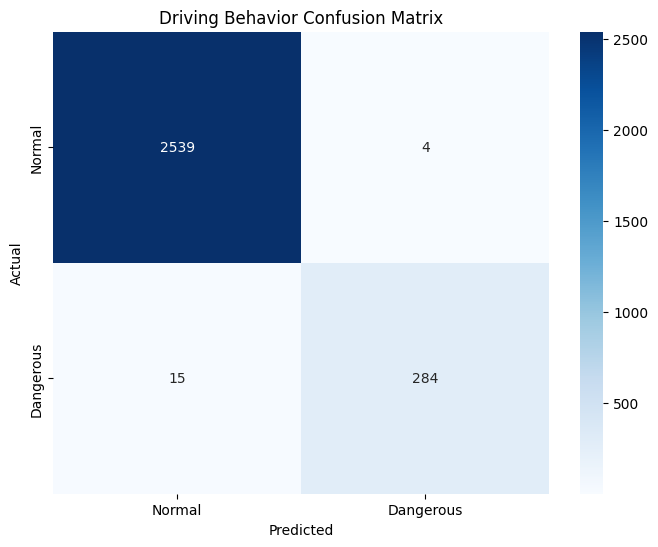

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      2543
   Dangerous       0.99      0.95      0.97       299

    accuracy                           0.99      2842
   macro avg       0.99      0.97      0.98      2842
weighted avg       0.99      0.99      0.99      2842



In [5]:
y_pred = best_model.predict(X_test)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CATEGORIES.keys(), yticklabels=CATEGORIES.keys())
plt.title("Driving Behavior Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, y_pred, target_names=CATEGORIES.keys()))

## Export

In [ ]:
js_code = m2c.export_to_javascript(best_model)
with open("drivingModelGyro.js", "w") as f:
    f.write("export const score = " + js_code)

print("Brain Exported successfully! Integration ready.")

## Generalization Tests

In [6]:
def run_blind_test(file_path, model):
    """
    Processes a raw trip file and returns a timeline of predictions.
    """
    df = pd.read_csv(file_path)
    predictions = []
    timestamps = []
    
    # We move through the trip in 2-second windows
    # Step size of 50 samples = 1 second (50% overlap for smooth timeline)
    for i in range(0, len(df) - 100, 50):
        window = df.iloc[i:i+100]
        features = extract_enhanced_features(window) # Using the function from previous cell
        
        # Get the prediction (0: Normal, 1: Aggressive, 2: Risky)
        pred = model.predict([features])[0]
        predictions.append(pred)
        
        # Use the index as a proxy for time (50Hz = 0.02s per sample)
        timestamps.append(i * 0.02) 
        
    return np.array(timestamps), np.array(predictions)


🚀 Starting Batch Inference on 7 files...


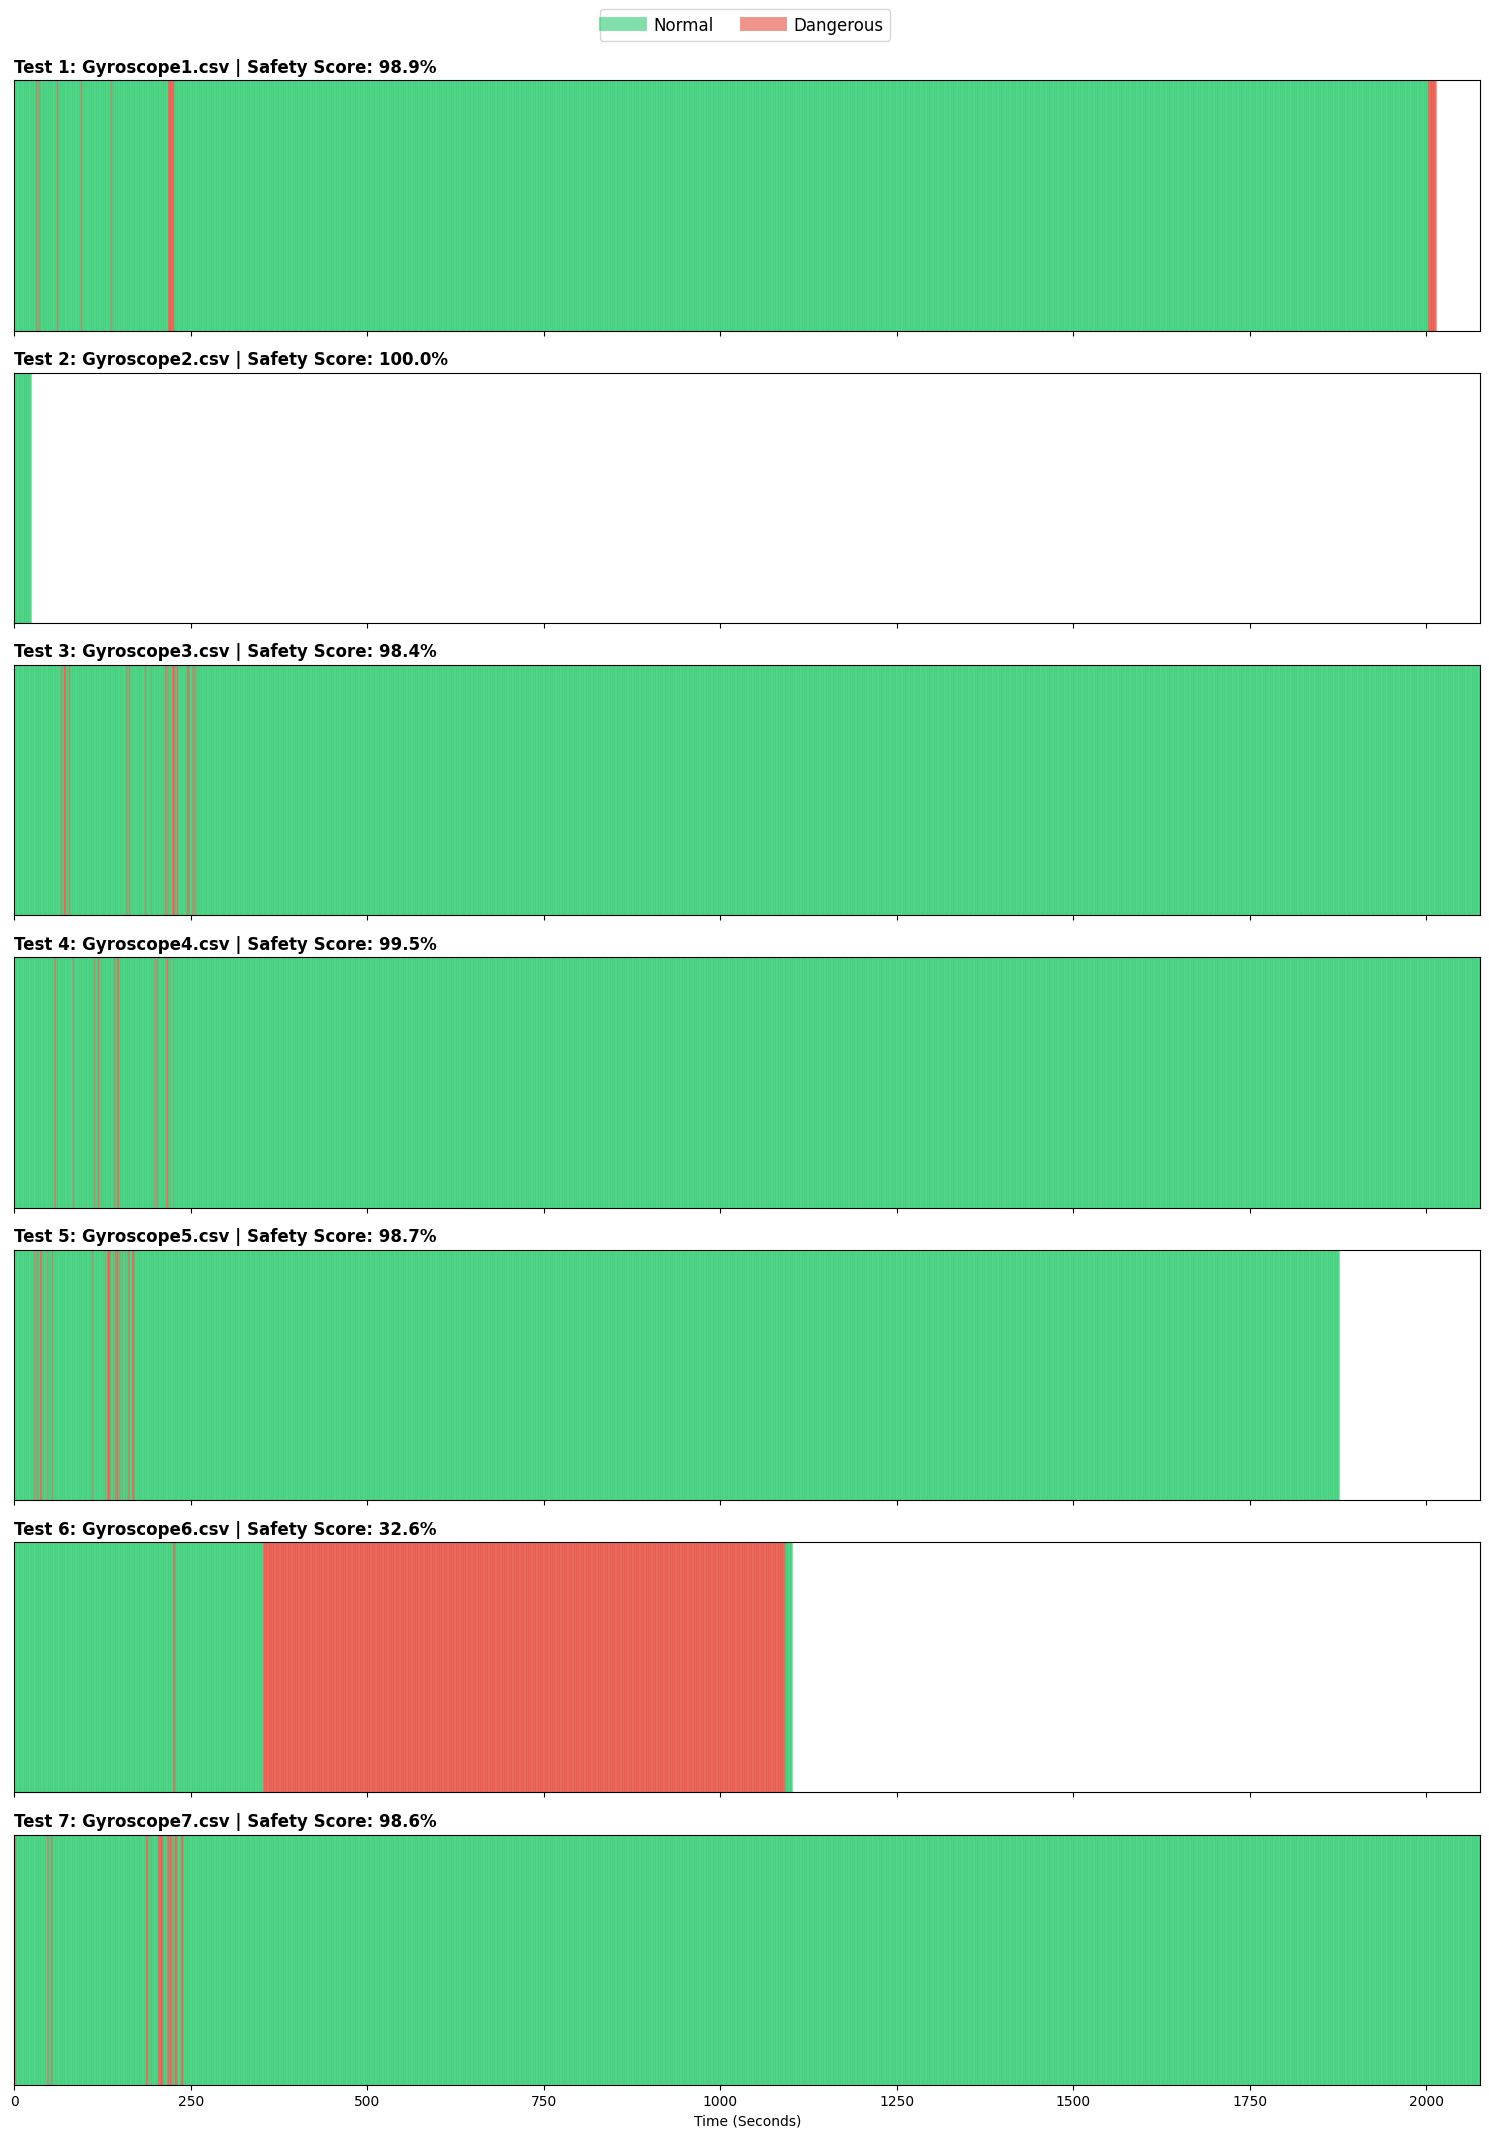

✅ Analysis Complete. Use this dashboard to identify 'Edge Cases' where your model is too sensitive.


In [8]:


# 1. Configuration
NUM_TESTS = 7
CATEGORIES = {0: 'Normal', 1: 'Dangerous'}
COLORS = {0: '#2ecc71', 1: '#e74c3c'} # Green, Red, Orange
BASE_PATH = "./datasetTest"

# 2. Setup Plotting Grid
fig, axes = plt.subplots(NUM_TESTS, 1, figsize=(15, 3 * NUM_TESTS), sharex=True)
fig.subplots_adjust(hspace=0.4)

print(f"🚀 Starting Batch Inference on {NUM_TESTS} files...")

# 3. Loop through each test file
for i in range(1, NUM_TESTS + 1):
    file_name = f"Gyroscope{i}.csv"
    file_path = os.path.join(BASE_PATH, file_name)
    ax = axes[i-1]
    
    if not os.path.exists(file_path):
        ax.text(0.5, 0.5, f"File Not Found: {file_name}", ha='center', va='center')
        continue

    # Run Inference
    times, preds = run_blind_test(file_path, best_model)
    
    # Plotting the timeline
    # We use 'fill_between' for a solid block look or 'axvspan' for segments
    for j in range(len(preds)):
        ax.axvspan(times[j], times[j] + 1, color=COLORS[preds[j]], alpha=0.4)
    
    # Calculate Safety Score for this specific test
    danger_count = np.sum(preds > 0)
    safety_score = max(0, 100 - (danger_count / len(preds) * 100))
    
    # Subplot Styling
    ax.set_title(f"Test {i}: {file_name} | Safety Score: {safety_score:.1f}%", loc='left', fontweight='bold')
    ax.set_yticks([])
    ax.set_xlim(0, max(times) + 1)
    
    if i == NUM_TESTS:
        ax.set_xlabel("Time (Seconds)")

# 4. Global Legend
for val, label in CATEGORIES.items():
    plt.plot([], [], color=COLORS[val], label=label, linewidth=10, alpha=0.6)
fig.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=12)

plt.tight_layout()
plt.show()

print("✅ Analysis Complete. Use this dashboard to identify 'Edge Cases' where your model is too sensitive.")